In [14]:
import os
import sys
import importlib.util
import ee
import folium
import geemap.foliumap as geemap
import geopandas as gpd
from IPython.display import display
import calendar # Import calendar for month name conversion
import rasterio
import matplotlib.pyplot as plt

In [ ]:
def load_module(name, rel_path):
    module_path = os.path.abspath(rel_path)
    spec = importlib.util.spec_from_file_location(name, module_path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module

sys.path.append(os.path.abspath("../scripts"))

aoi_loader      = load_module("aoi_loader", "../scripts/aoi_loader.py")

In [4]:
aoi_gdf = aoi_loader.load_shapefile_as_gdf("../data/local/aoi.shp")
print(type(aoi_gdf))


m = folium.Map(location=[44.560052, 12.282671], zoom_start=12)
folium.GeoJson(aoi_gdf).add_to(m)

""" m.save("map_aoi.html")
print("Saved 'map_aoi.html' in the current directory")
 """
from IPython.display import display
display(m)

<class 'geopandas.geodataframe.GeoDataFrame'>


In [5]:
ee.Authenticate()
ee.Initialize()

In [6]:
aoi = geemap.geopandas_to_ee(aoi_gdf, geodesic=False)

In [ ]:
months = [4, 5, 6, 7, 8, 9]
year = 2024
monthly_vv_images = []
valid_months = []

for month in months:
    start = ee.Date(f'{year}-{month:02d}-01')
    end = start.advance(1, 'month')
    
    s1_month = ee.ImageCollection('COPERNICUS/S1_GRD') \
        .filterBounds(aoi) \
        .filterDate(start, end) \
        .filter(ee.Filter.eq('instrumentMode', 'IW')) \
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV')) \
        .select('VV')

    count = s1_month.size().getInfo()
    print(f"🗓️ {calendar.month_name[month]} {year}: {count} images")

    if count == 0:
        print(f"⚠️ Skipping {calendar.month_name[month]} – no data found.\n")
        continue

    vv_image = s1_month.median().clip(aoi)
    monthly_vv_images.append(vv_image)
    valid_months.append(month)

    # exporta in drive
    filename = f"s1sar_vv_{calendar.month_abbr[month].lower()}{str(year)[-2:]}"
    task = ee.batch.Export.image.toDrive(
        image=vv_image,
        description=filename,
        folder='GEE_exports',
        fileNamePrefix=filename,
        scale=10,
        region=aoi.geometry(),
        crs='EPSG:4326',
        maxPixels=1e13
    )
    task.start()
    print(f"✅ Exporting: {filename}\n")

# mean apr–sep
if monthly_vv_images:
    combined_mean = ee.ImageCollection(monthly_vv_images).mean()
    task_mean = ee.batch.Export.image.toDrive(
        image=combined_mean,
        description='s1sar_vv_mean_apr_sep',
        folder='GEE_exports',
        fileNamePrefix='s1sar_vv_mean_apr_sep',
        scale=10,
        region=aoi.geometry(),
        crs='EPSG:4326',
        maxPixels=1e13
    )
    task_mean.start()
    print("📦 Exporting overall mean: s1sar_vv_mean_apr_sep")
else:
    print("❌ No valid months found — skipping overall mean export.")


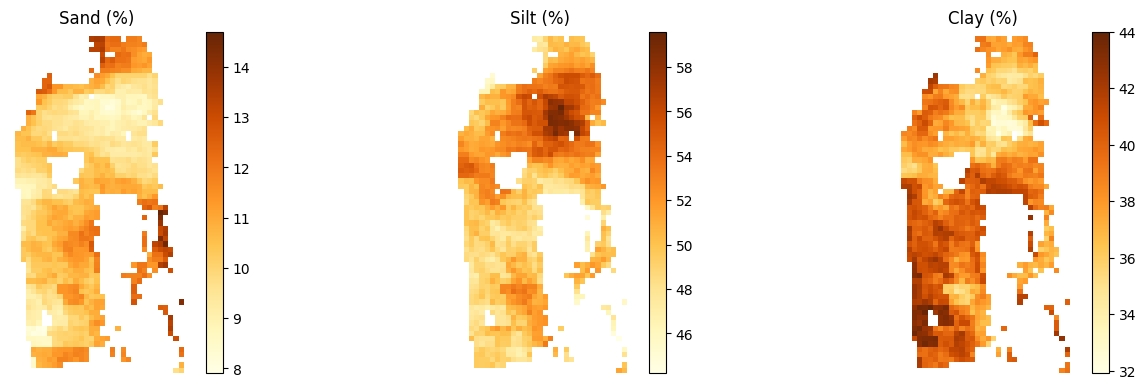

In [15]:
sand_path = "../data/outputs/raster/isric/raster/sand_0_5_div10.tif"
silt_path = "../data/outputs/raster/isric/raster/silt_0_5_div10.tif"
clay_path = "../data/outputs/raster/isric/raster/clay_0_5_div10.tif"

with rasterio.open(sand_path) as sand_src:
    sand = sand_src.read(1)
    sand_profile = sand_src.profile

with rasterio.open(silt_path) as silt_src:
    silt = silt_src.read(1)

with rasterio.open(clay_path) as clay_src:
    clay = clay_src.read(1)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ['Sand (%)', 'Silt (%)', 'Clay (%)']
data = [sand, silt, clay]

for ax, d, t in zip(axes, data, titles):
    im = ax.imshow(d, cmap='YlOrBr')
    ax.set_title(t)
    ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
